## 12-06-2026 EXPLORATORY DATA ANALYSIS (EDA)
EDA is where we get to know the data deeply — cleaning it, summarizing it, visualizing it, and spotting patterns before we jump into modeling.

We'll use the Pima Indians Diabetes dataset. It has medical measurements for women, and the goal is to predict whether they have diabetes (Outcome = 1) or not (0). This is a classic beginner dataset that teaches us a full pipeline.

My personal style: I like to think of EDA as detective work. We load the data, ask 'what's weird here?', fix problems, draw pictures to understand relationships, and only then build a simple model to see if our understanding helps.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(42)

### 1. Loading and First Look
I always start by loading the data and peeking at it. `head()` shows the first few rows so I can see what the columns mean in real numbers.

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 2. Basic Information
`info()` tells me the size, data types, and if there are any obvious missing values. `describe()` gives me all the descriptive statistics we learned in class 1 — mean, median, std, min/max, quartiles.

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               71 non-null     int64  
 1   Glucose                   71 non-null     int64  
 2   BloodPressure             71 non-null     int64  
 3   SkinThickness             71 non-null     int64  
 4   Insulin                   71 non-null     int64  
 5   BMI                       71 non-null     float64
 6   DiabetesPedigreeFunction  71 non-null     float64
 7   Age                       71 non-null     int64  
 8   Outcome                   71 non-null     int64  
dtypes: float64(2), int64(7)
memory usage: 5.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000
mean,4.830986,124.126761,70.830986,16.450704,85.394366,30.828169,0.464366,34.507042,0.492958
std,3.047181,31.906081,17.188024,16.177399,145.323922,7.563846,0.349817,10.684934,0.503509
min,0.000000,74.000000,0.000000,0.000000,0.000000,0.000000,0.134000,21.000000,0.000000
25%,3.000000,102.500000,64.500000,0.000000,0.000000,25.700000,0.241500,26.000000,0.000000
50%,4.000000,118.000000,72.000000,15.000000,0.000000,29.700000,0.388000,31.000000,0.000000
75%,7.000000,146.000000,80.000000,30.500000,112.500000,35.000000,0.583000,42.000000,1.000000
max,13.000000,197.000000,96.000000,47.000000,846.000000,46.200000,2.288000,59.000000,1.000000


### 3. Spotting Problems — The Zero Trap
Look at the min values. Glucose, BloodPressure, SkinThickness, Insulin, BMI can't realistically be zero for a living person. These are missing values coded as 0. I replace them with NaN so we can handle them properly.

In [4]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)
print(df.isnull().sum())

Pregnancies                  0
Glucose                      0
BloodPressure                2
SkinThickness               31
Insulin                     37
BMI                          1
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64


### 4. Imputing Missing Values
For symmetric columns I use mean, for skewed ones median (remember from class 1 — median is robust to outliers). This is practical statistics in action.

In [5]:
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].mean())
df['BloodPressure'] = df['BloodPressure'].fillna(df['BloodPressure'].mean())
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())
df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].median())
df['Insulin'] = df['Insulin'].fillna(df['Insulin'].median())

### 5. Visualizing Distributions
Histograms show the shape of each feature. Boxplots help spot outliers. This is where we see skewness in real data.

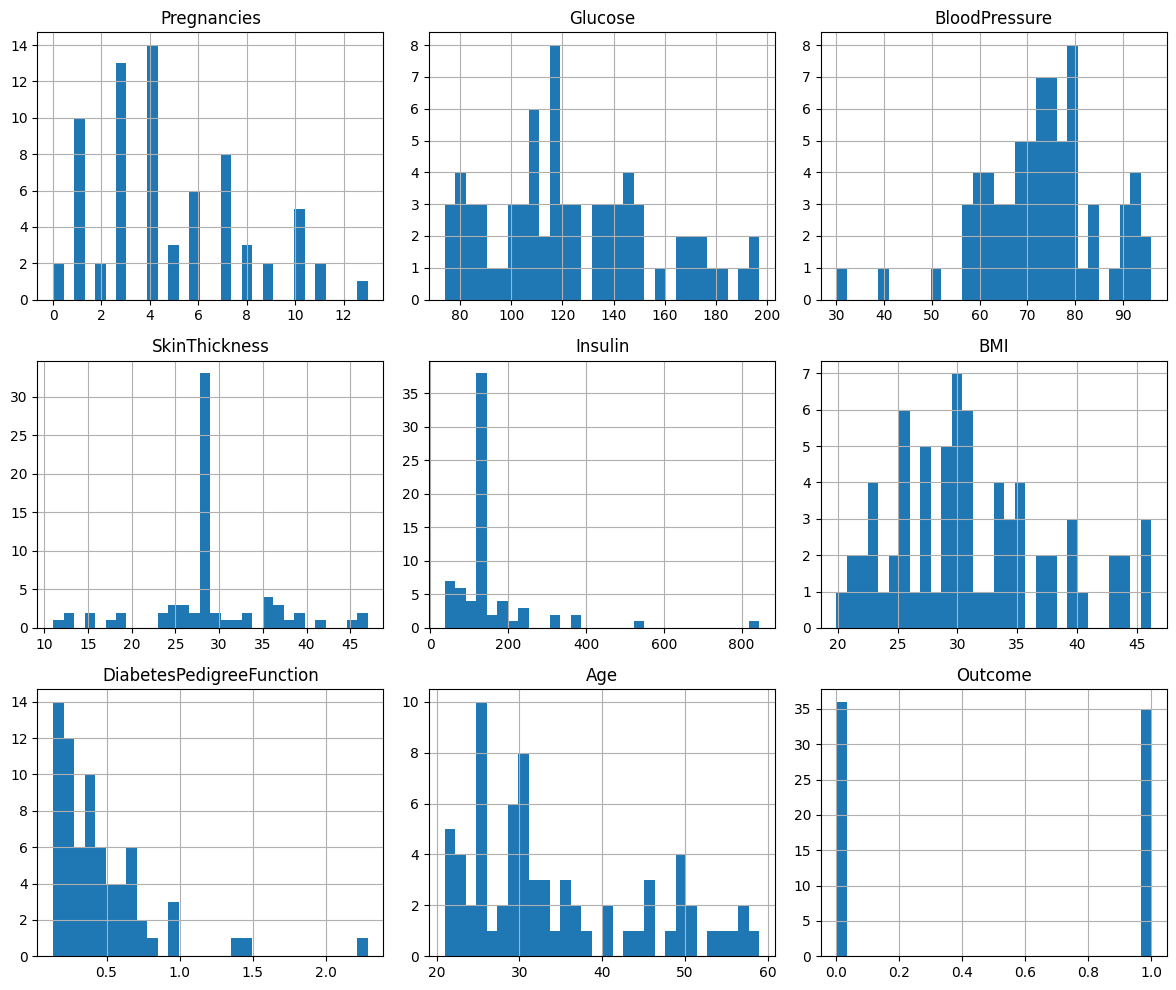

In [6]:
df.hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()

### 6. Class Balance and Relationships
Check how balanced the target is. Then use pairplot and correlation heatmap to see relationships between features.

Outcome
0    0.507042
1    0.492958
Name: proportion, dtype: float64


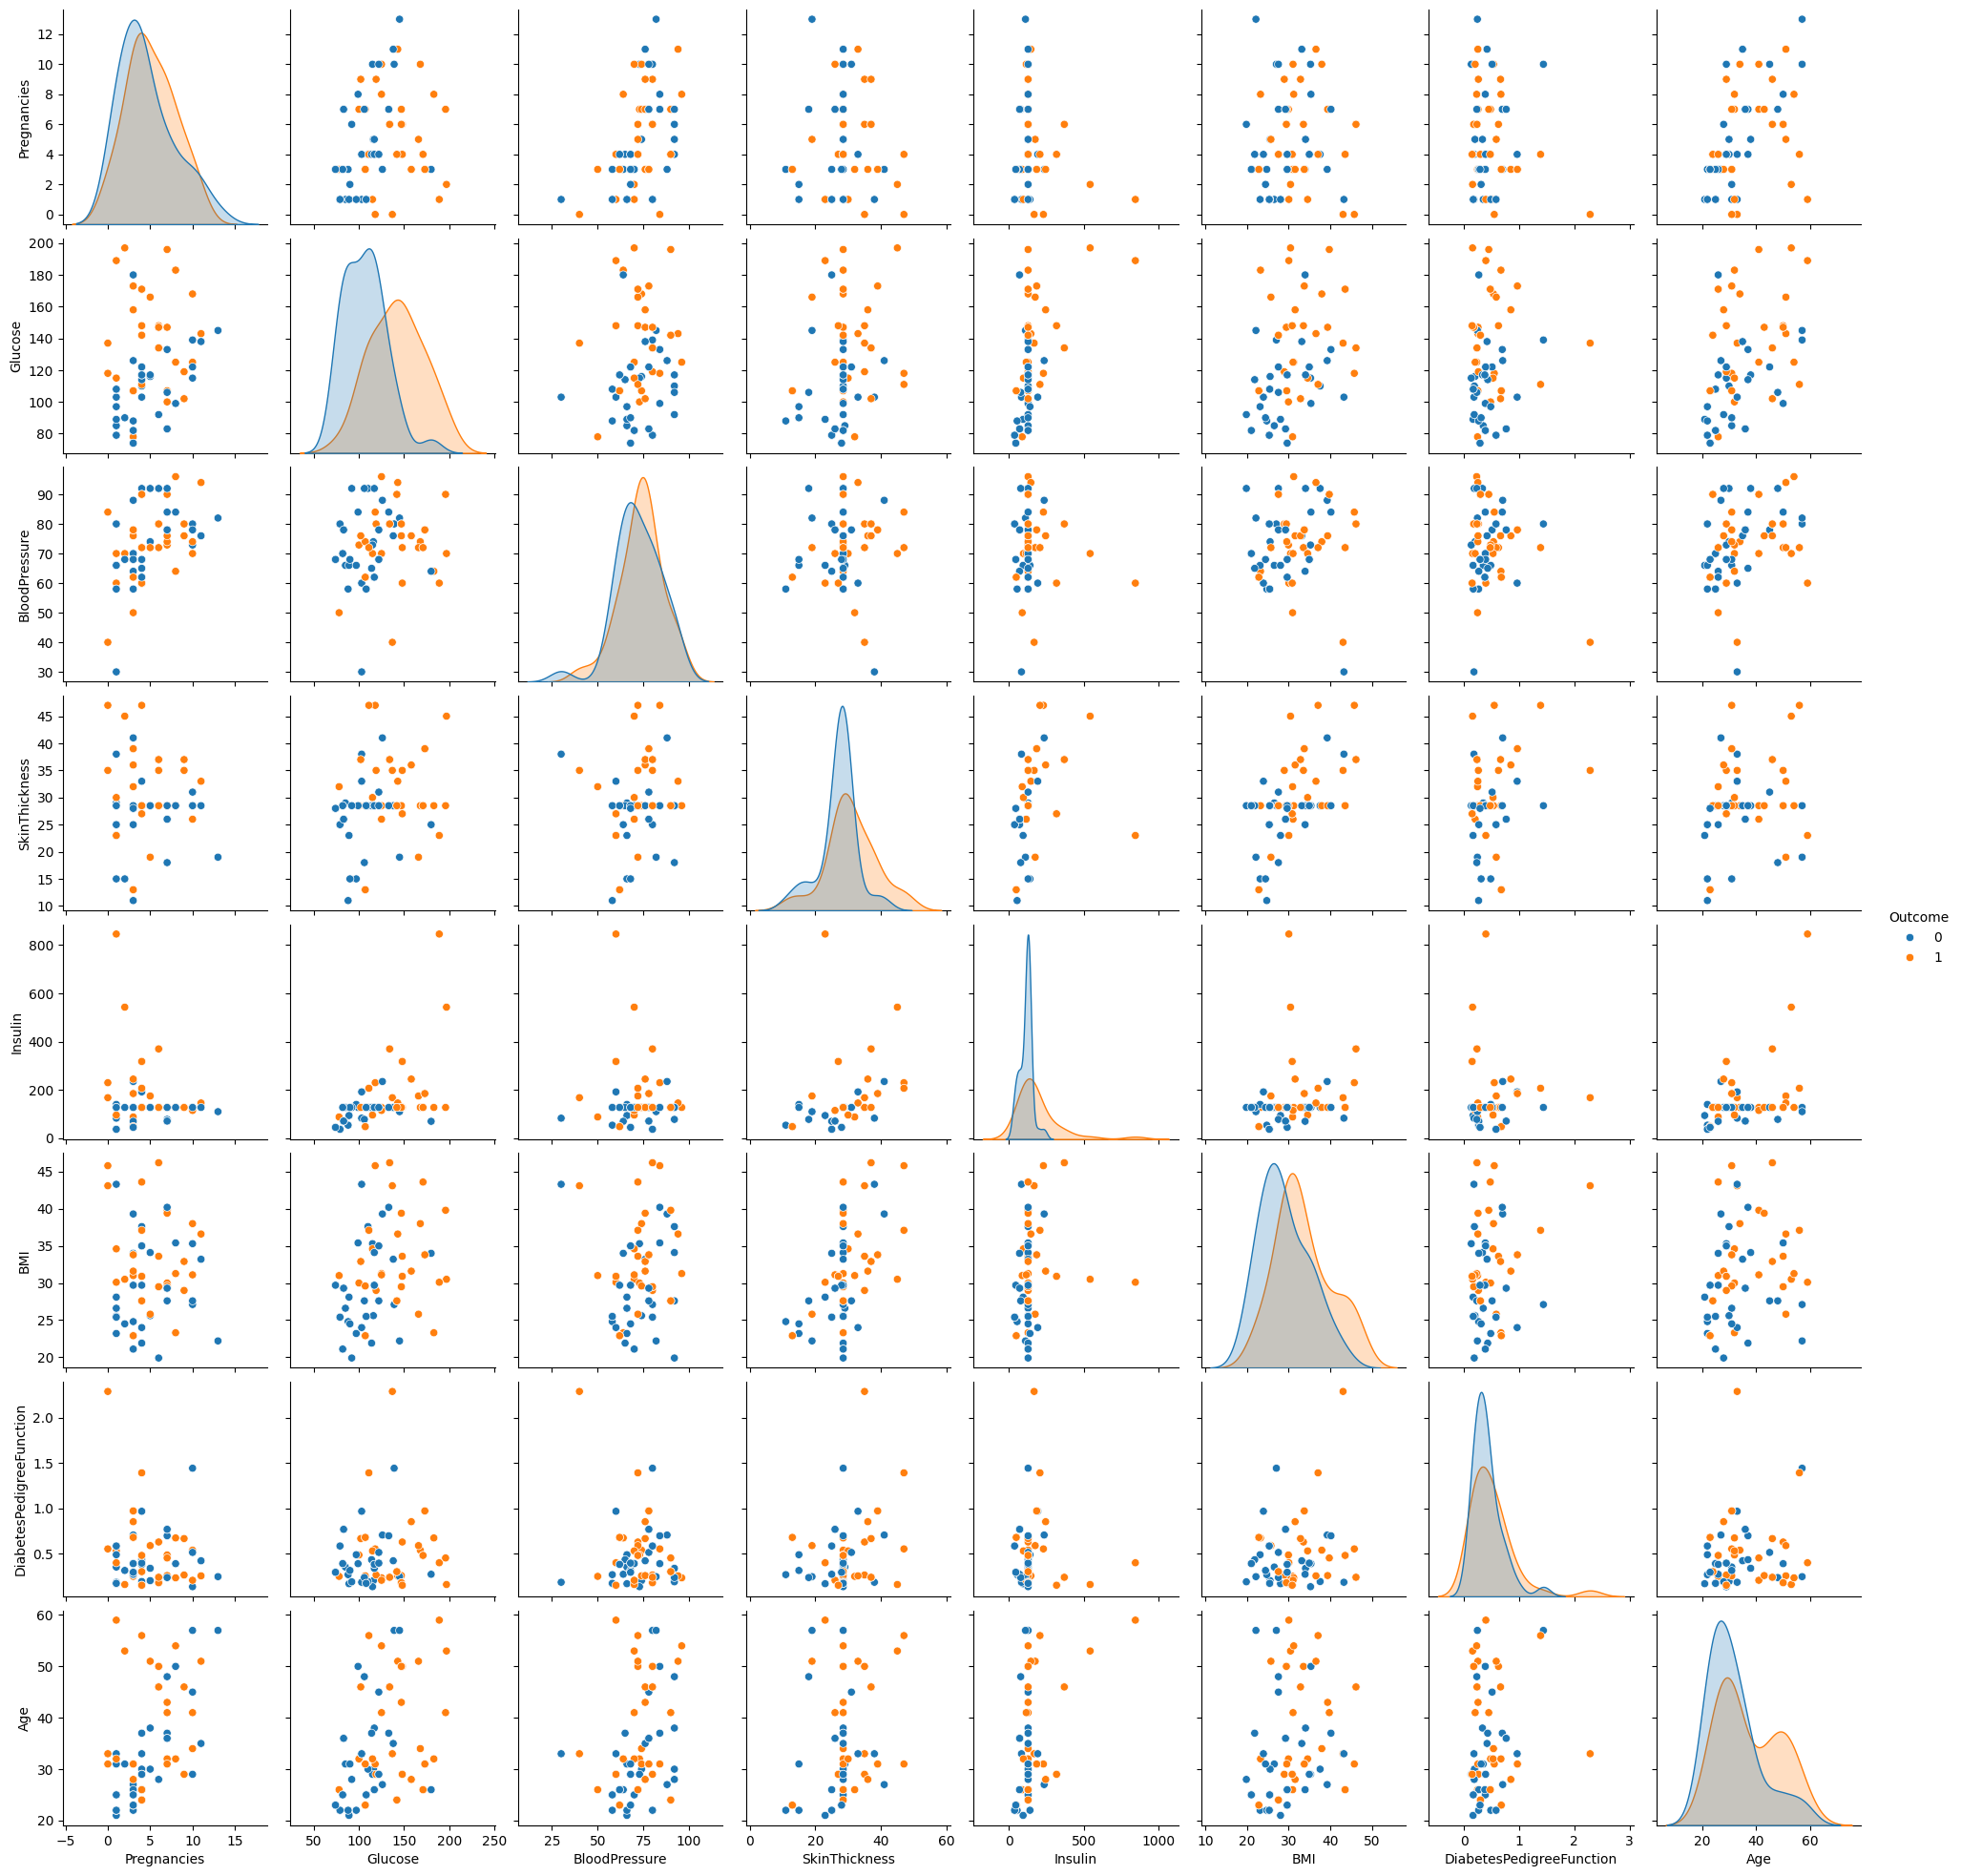

In [7]:
print(df['Outcome'].value_counts(normalize=True))
sns.pairplot(df, hue='Outcome', diag_kind='kde')
plt.show()

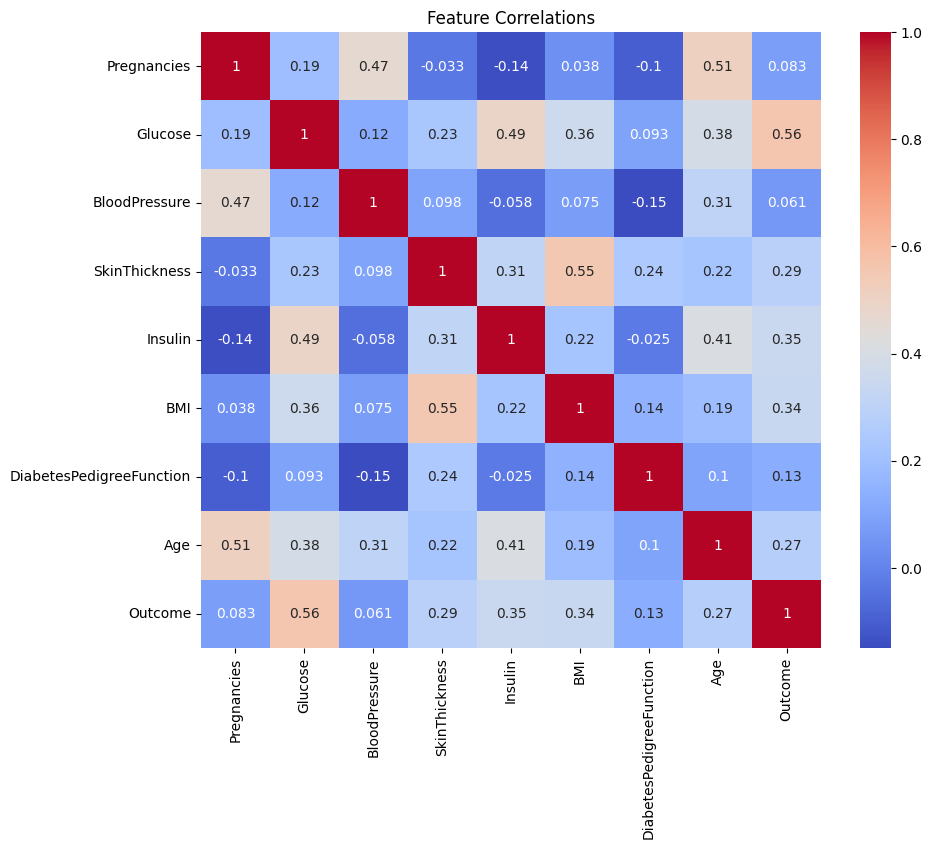

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()

### 7. Feature Scaling
Most algorithms like standardized data (mean 0, std 1). This makes features comparable.

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_scaled = scaler.fit_transform(X)

### 8. Train-Test Split and Simple Model
I split the data and try a basic KNN classifier. This shows how our EDA helps us build something useful.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)
print('Accuracy:', accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.7333333333333333
              precision    recall  f1-score   support

           0       0.78      0.78      0.78         9
           1       0.67      0.67      0.67         6

    accuracy                           0.73        15
   macro avg       0.72      0.72      0.72        15
weighted avg       0.73      0.73      0.73        15



### Recap
- Loaded data and inspected with head/info/describe
- Found and fixed missing values (zeros)
- Imputed using mean/median based on distribution shape
- Visualized with histograms, pairplots, correlation heatmaps
- Scaled features
- Built and evaluated a simple KNN model

EDA is the foundation. The better we understand the data, the better our models will be. Tomorrow we'll go deeper into modeling and feature engineering!